Overview of dataset : 
1. Number of Pregnancies: Number of times pregnant.

2. Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.

3. Blood Pressure: Diastolic blood pressure (mm Hg).

4. Skin Thickness: Triceps skin fold thickness (mm).

5. Insulin: 2-Hour serum insulin (mu U/ml).

6. BMI: Body mass index (weight in kg/(height in m)^2).

7. Diabetes Pedigree Function: A function that scores likelihood of diabetes based on family history.

8. Age: Age in years.

9. Outcome: Class variable (0 if non-diabetic, 1 if diabetic).

In this work, we are working on 5 models:
- Logistic regression
- Random Forest 
- Support Vector Machine
- K-Nearest Neighbors (KNN)
- decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


%matplotlib inline
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load dataset


In [2]:
data=pd.read_csv('../Dataset/pima-indians-diabetes.csv');


1- Data Processing

1.1- Exploring about our dataset

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


1.2- Data cleaning

In [5]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


1.2- EDA

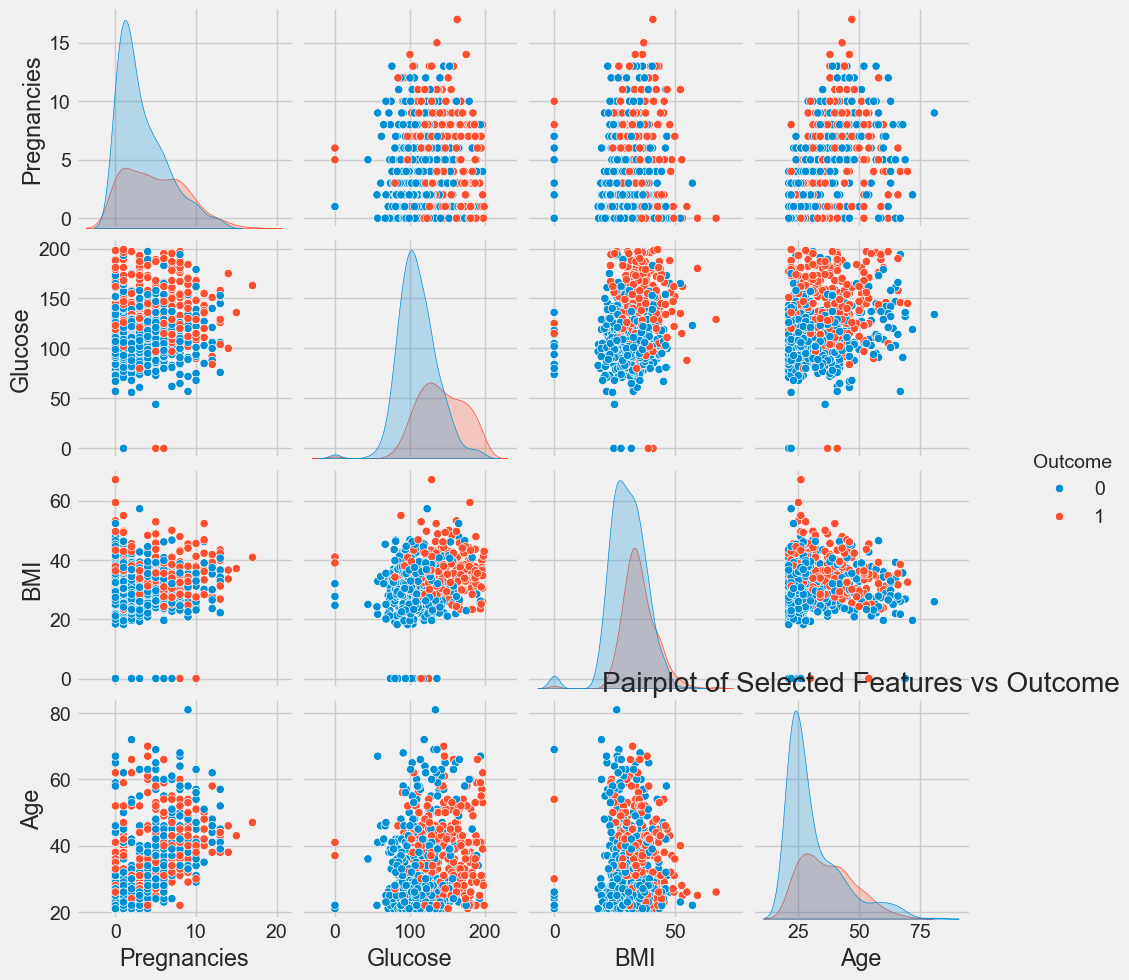

In [6]:
# Pairplot to visualize the relationship between selected features
sns.pairplot(data, hue='Outcome', vars=['Pregnancies', 'Glucose', 'BMI', 'Age'])
plt.title('Pairplot of Selected Features vs Outcome')
plt.show()

Check the balance of data set for target feature 'Outcome'

Outcome
0    500
1    268
Name: count, dtype: int64


C:\Users\USERR\AppData\Local\Temp\ipykernel_32452\2482176011.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=data, palette='Set2')


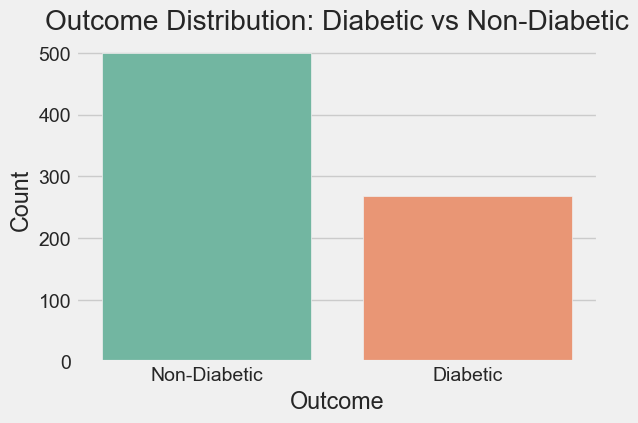

In [7]:
print(data['Outcome'].value_counts())
# Bar plot for the Outcome distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data, palette='Set2')
plt.title('Outcome Distribution: Diabetic vs Non-Diabetic')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic', 'Diabetic'])
plt.show()

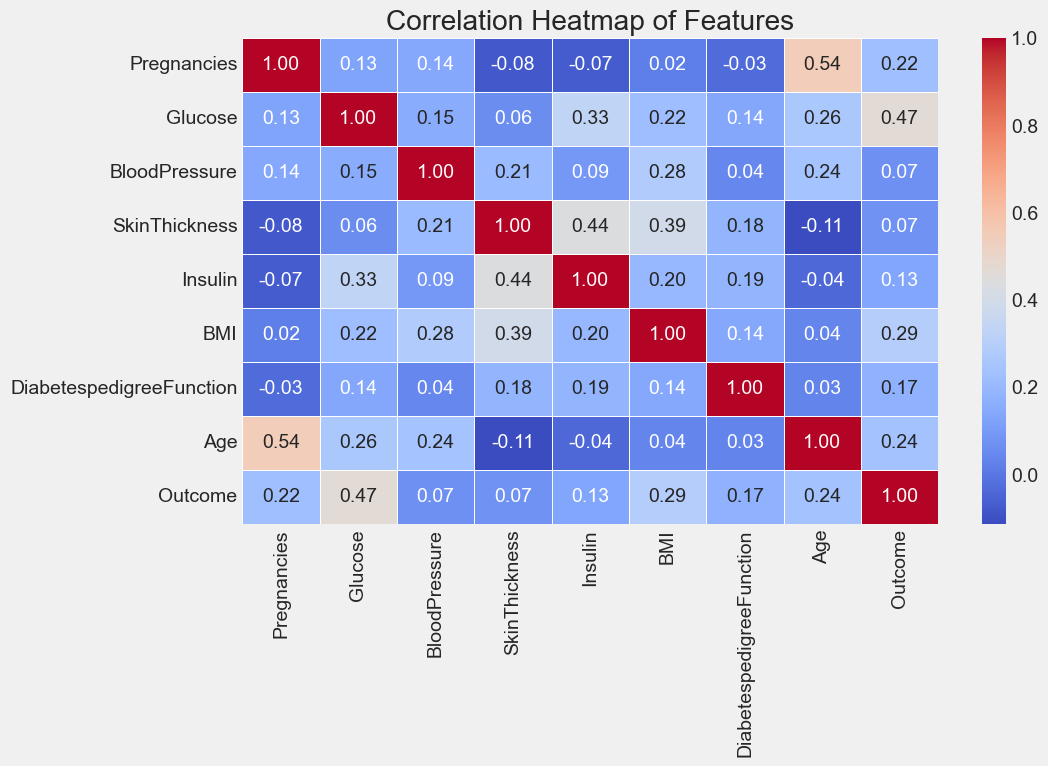

In [8]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()


Drop less relevant columns 

In [9]:
data.drop(['BloodPressure', 'SkinThickness', 'Insulin','DiabetespedigreeFunction'], axis=1, inplace=True)
data.columns

Index(['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome'], dtype='object')

2- Train model and evauluation different model

2.1-Deal with imbalance dataset

Split dataset for training and testing , 80:20

In [10]:
# Separate the features and the target variable
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the train and test sets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (614, 4)
Testing set size: (154, 4)


Check balance of data for both training and testing data set

In [11]:
# Optional: Check class distribution in the training and testing sets
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts())


Class distribution in training set:
Outcome
0    401
1    213
Name: count, dtype: int64

Class distribution in testing set:
Outcome
0    99
1    55
Name: count, dtype: int64


Balancing the data for training dataset by oversampling technique 

In [12]:
# Apply SMOTE to the training set to balance the class distribution
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new class distribution in the training set after SMOTE
print("\nClass distribution in training set after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Class distribution in training set after SMOTE:
Outcome
0    401
1    401
Name: count, dtype: int64


2.2- Train and evaluate with Logistic Regression Model

In [13]:
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression model
LogisticRegression_model = LogisticRegression(random_state=42)

# Train the model on the oversampled training data
LogisticRegression_model.fit(X_train_resampled, y_train_resampled)
# Predict on the test data
y_pred = LogisticRegression_model.predict(X_test)
# Evaluate the model performance
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy on Test Data: 0.7077922077922078

Confusion Matrix:
[[70 29]
 [16 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76        99
           1       0.57      0.71      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154



2.3- Train and evaluate with Random Forest Model

In [14]:
from sklearn.ensemble import RandomForestClassifier
# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_resampled, y_train_resampled)
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
print("Random Forest Accuracy on Test Data:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# ✅ Save the trained model
with open("random_forest_model.pkl", "wb") as model_file:
    pickle.dump(rf_model, model_file)

print("✅ Model saved as 'random_forest_model.pkl'")

Random Forest Accuracy on Test Data: 0.7337662337662337

Random Forest Confusion Matrix:
[[74 25]
 [16 39]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        99
           1       0.61      0.71      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

✅ Model saved as 'random_forest_model.pkl'


2.4- Train and evaluate with Support Vector Machine Model

In [15]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model = SVC(random_state=42)

# Train the model
svm_model.fit(X_train_resampled, y_train_resampled)
# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
print("SVM Accuracy on Test Data:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy on Test Data: 0.7077922077922078

SVM Confusion Matrix:
[[69 30]
 [15 40]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.70      0.75        99
           1       0.57      0.73      0.64        55

    accuracy                           0.71       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154



2.5- Train and evaluate with K-Nearest Neighbors Model

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn_model = KNeighborsClassifier()

# Train the model
knn_model.fit(X_train_resampled, y_train_resampled)
y_pred_knn = knn_model.predict(X_test)

# Evaluate the KNN model
print("KNN Accuracy on Test Data:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy on Test Data: 0.7207792207792207

KNN Confusion Matrix:
[[70 29]
 [14 41]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.74      0.72      0.73       154



2.6- Train and evauluate with Decision Tree model

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the oversampled training data
dt_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model
print("Decision Tree Accuracy on Test Data:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy on Test Data: 0.6623376623376623

Decision Tree Confusion Matrix:
[[68 31]
 [21 34]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72        99
           1       0.52      0.62      0.57        55

    accuracy                           0.66       154
   macro avg       0.64      0.65      0.65       154
weighted avg       0.68      0.66      0.67       154

